# E-Commerce Customer Churn — EDA & SQL Analysis
**Dataset:** ecommerce_customer_churn_dataset.csv (50,000 customers)  
**Goal:** Understand what drives customer churn and answer 10 business questions using Python EDA and SQL queries.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = pd.read_csv('data/ecommerce_customer_churn_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 25)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 2. Data Understanding

In [3]:
# Column types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [4]:
# Basic statistics
df.describe().round(2)

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.00,50000.00,50000.00,46601.00,47000.00,50000.00,46000.00,50000.00,50000.00,47000.00,...,45509.00,47472.00,49832.00,46500.00,44000.00,45000.00,47500.00,50000.00,44500.00,50000.00
mean,37.80,2.98,11.62,27.66,8.74,57.08,4.30,13.11,123.12,29.79,...,6.68,20.94,5.68,2.85,29.36,19.37,2.35,1440.63,1966.23,0.29
std,11.83,2.06,7.81,10.87,3.78,16.28,3.19,7.02,175.57,29.70,...,6.14,14.25,2.68,2.33,20.57,9.42,1.11,907.25,1225.07,0.45
min,5.00,0.10,0.00,1.00,1.00,0.00,0.00,-13.00,26.38,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,29.00,1.40,6.00,19.70,6.00,46.40,2.00,8.00,87.05,9.00,...,2.90,9.90,4.00,1.00,13.20,12.50,2.00,789.82,1049.00,0.00
50%,38.00,2.50,11.00,26.80,8.40,58.10,4.00,12.00,112.97,21.00,...,5.40,19.70,5.00,2.00,27.60,18.60,2.00,1243.42,1896.00,0.00
75%,46.00,4.00,17.00,34.70,11.20,68.70,6.00,17.00,144.44,41.00,...,9.10,30.40,7.00,4.00,43.10,25.50,3.00,1874.00,2791.00,1.00
max,200.00,10.00,46.00,75.60,24.10,143.74,28.00,128.70,9666.38,287.00,...,99.62,91.70,21.00,21.00,100.00,61.90,5.00,8987.24,7197.00,1.00


In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
print(missing)
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values:
Age                              2495
Session_Duration_Avg             3399
Pages_Per_Session                3000
Wishlist_Items                   4000
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Credit_Balance                   5500
dtype: int64

Total missing: 49081


## 3. Data Cleaning

In [6]:
# Fill numeric nulls with median, categorical with mode
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')
print(f'Clean dataset shape: {df.shape}')

Duplicates removed: 0
Clean dataset shape: (50000, 25)


## 4. Exploratory Data Analysis (EDA)

Churn Distribution:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


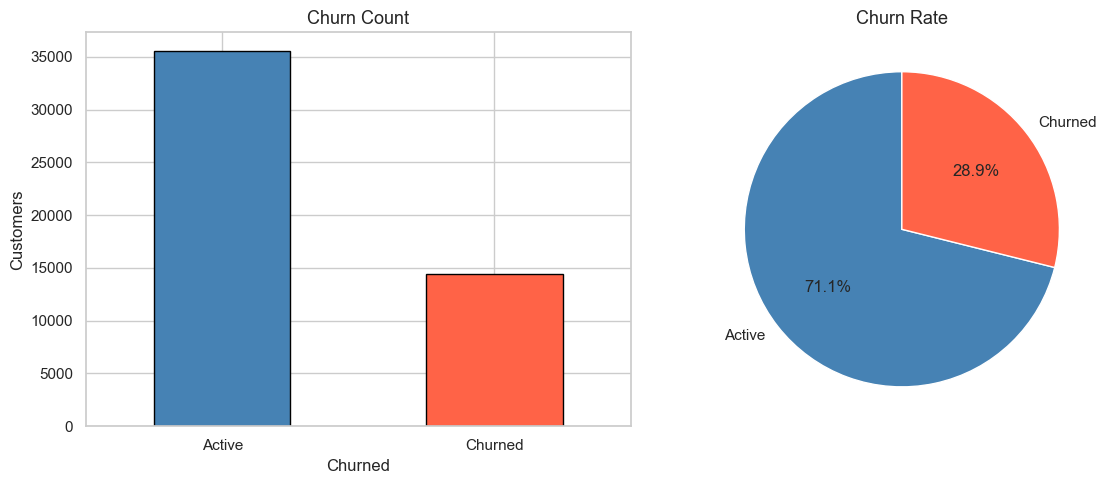

In [7]:
# Overall churn rate
churn_rate = df['Churned'].value_counts(normalize=True) * 100
print('Churn Distribution:')
print(churn_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Churned'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xticklabels(['Active', 'Churned'], rotation=0)
axes[0].set_ylabel('Customers')

axes[1].pie(df['Churned'].value_counts(), labels=['Active', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Rate', fontsize=13)
plt.tight_layout()
plt.savefig('data/churn_distribution.png', dpi=120)
plt.show()

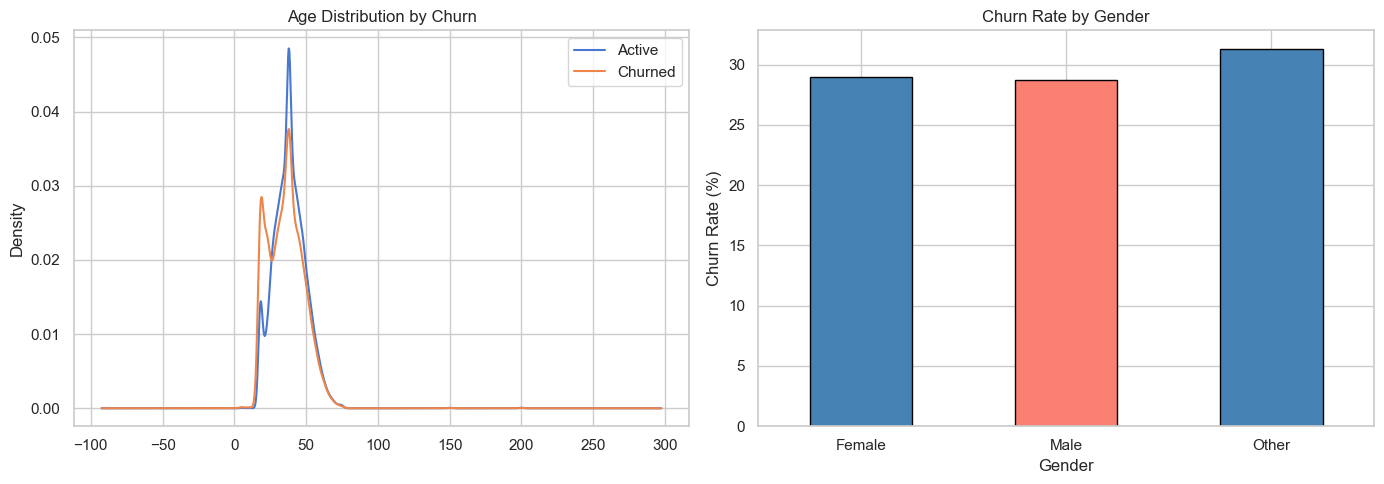

In [8]:
# Age distribution by churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in df.groupby('Churned'):
    name = 'Churned' if label == 1 else 'Active'
    group['Age'].plot(kind='kde', ax=axes[0], label=name)
axes[0].set_title('Age Distribution by Churn')
axes[0].legend()

# Gender vs churn
gender_churn = df.groupby('Gender')['Churned'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(gender_churn.index, rotation=0)
plt.tight_layout()
plt.savefig('data/age_gender_churn.png', dpi=120)
plt.show()

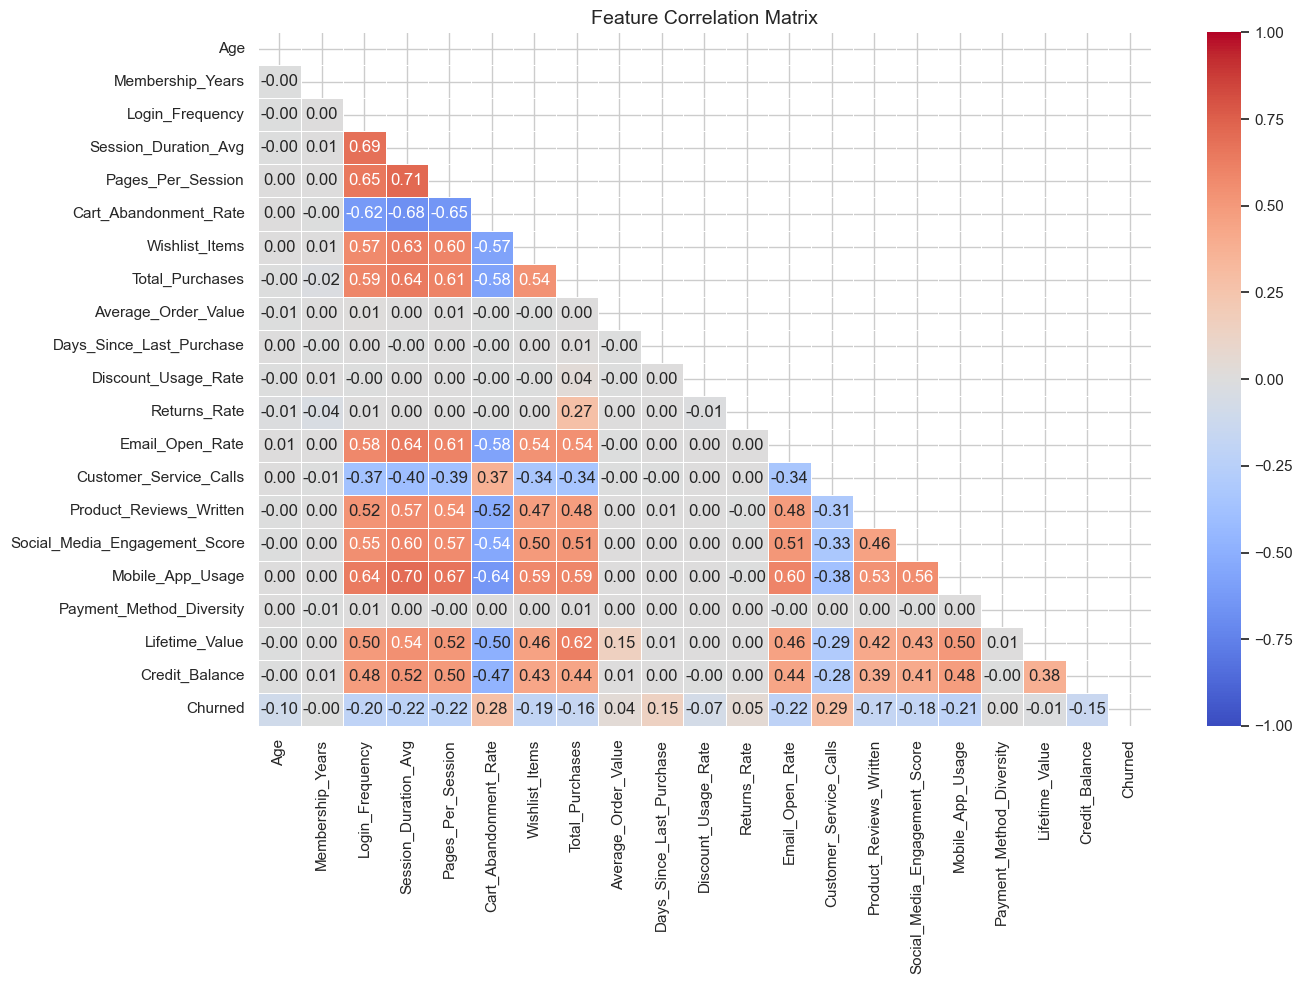

In [9]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=120)
plt.show()

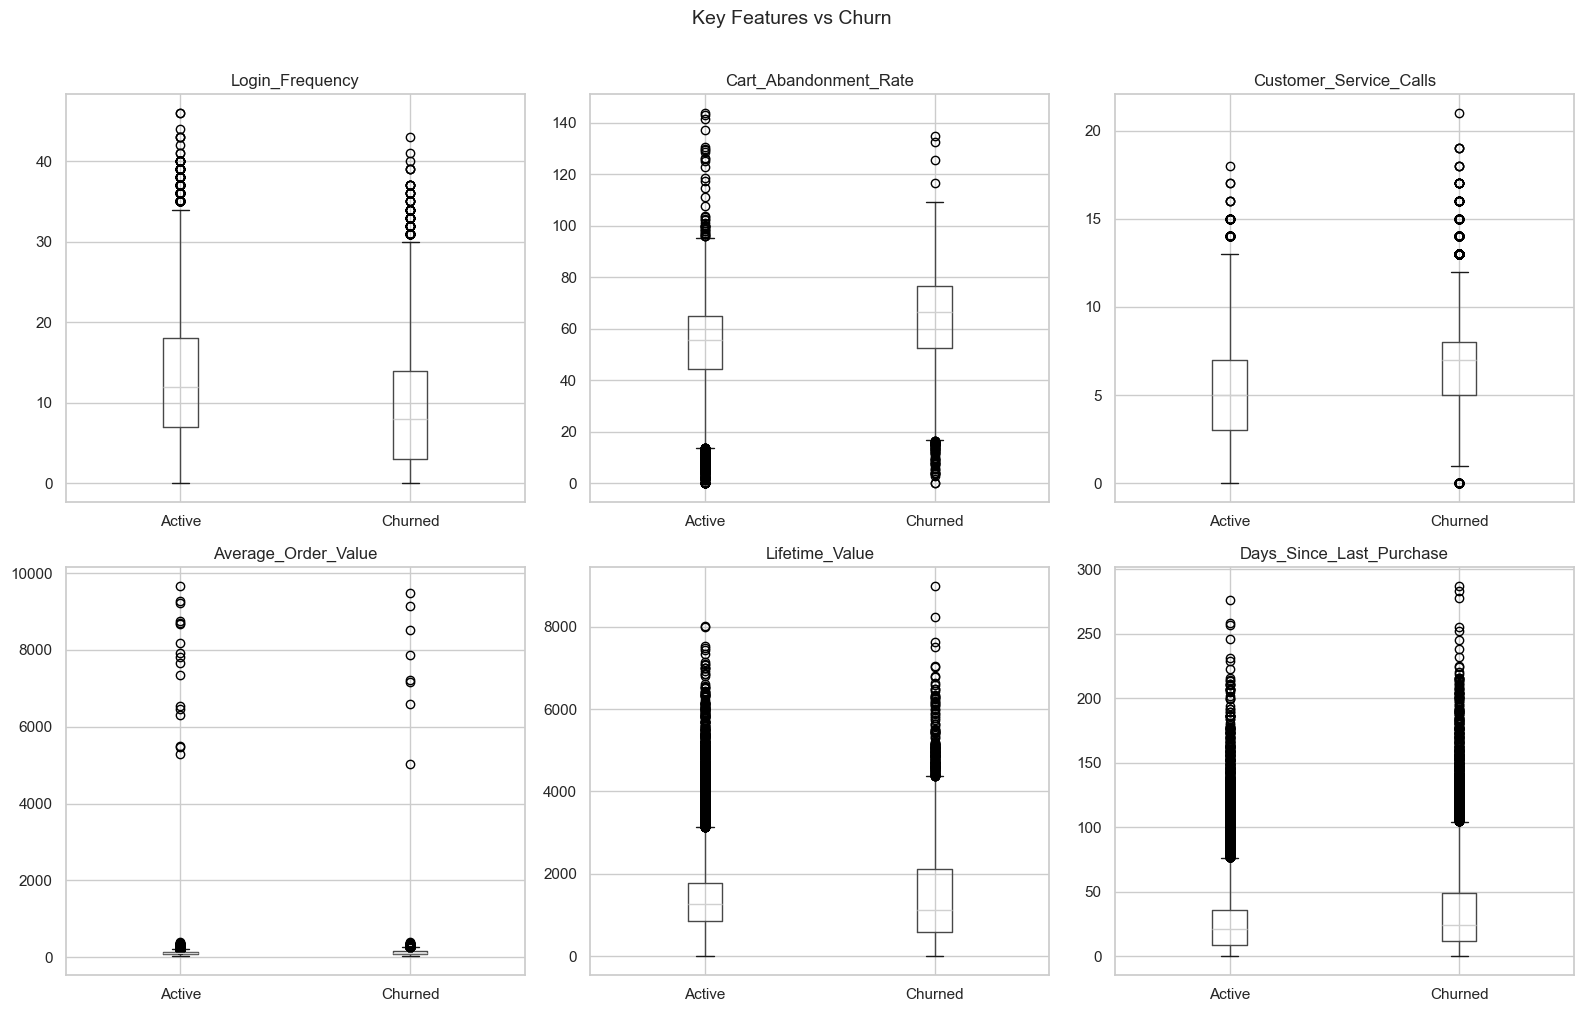

In [10]:
# Key numeric features vs Churn
key_features = ['Login_Frequency', 'Cart_Abandonment_Rate', 'Customer_Service_Calls',
                'Average_Order_Value', 'Lifetime_Value', 'Days_Since_Last_Purchase']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, by='Churned', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Active', 'Churned'])

plt.suptitle('Key Features vs Churn', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('data/features_vs_churn.png', dpi=120)
plt.show()

## 5. Load Data into SQLite

In [11]:
# Create SQLite database and load the dataframe
conn = sqlite3.connect('data/ecommerce.db')
df.to_sql('customers', conn, if_exists='replace', index=True, index_label='customer_id')
print('Data loaded into SQLite successfully!')
print(f'Table: customers | Rows: {len(df)}')

Data loaded into SQLite successfully!
Table: customers | Rows: 50000


## 6. Business Questions — SQL Queries

### Q1: What is the overall churn rate?

In [12]:
query = """
SELECT 
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct,
    SUM(Churned) AS total_churned,
    COUNT(*) - SUM(Churned) AS total_active,
    COUNT(*) AS total_customers
FROM customers
"""
pd.read_sql(query, conn)

,churn_rate_pct,total_churned,total_active,total_customers
0,28.9,14450,35550,50000


### Q2: How does churn rate vary by country?

  Country  total_customers  churned  churn_rate_pct
Australia             4061     1214           29.89
   Canada             6023     1768           29.35
      USA            17384     5056           29.08
    India             3512     1019           29.01
  Germany             4925     1420           28.83
       UK             7534     2169           28.79
    Japan             2548      709           27.83
   France             4013     1095           27.29


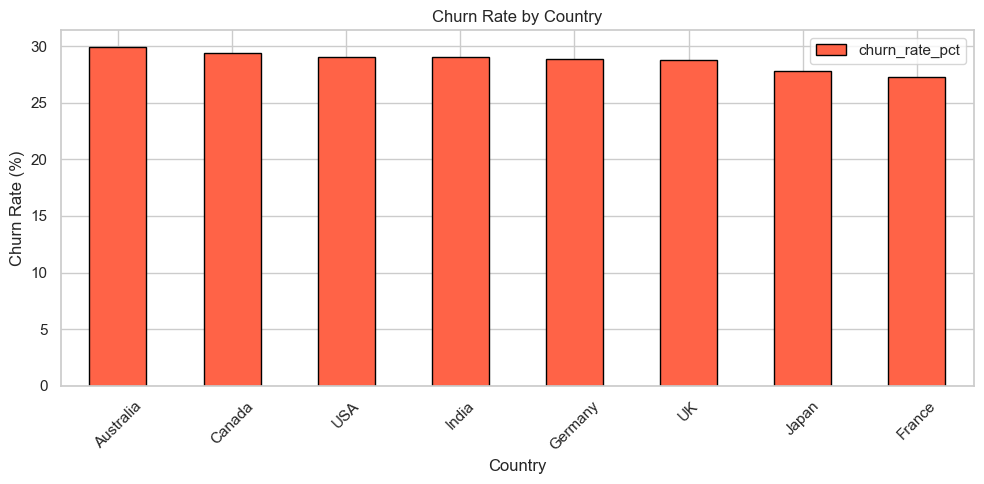

In [13]:
query = """
SELECT 
    Country,
    COUNT(*) AS total_customers,
    SUM(Churned) AS churned,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY Country
ORDER BY churn_rate_pct DESC
"""
result = pd.read_sql(query, conn)
print(result.to_string(index=False))

# Visualization
result.plot(kind='bar', x='Country', y='churn_rate_pct', color='tomato', edgecolor='black')
plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/churn_by_country.png', dpi=120)
plt.show()

### Q3: Do customers with higher cart abandonment rates churn more?

In [14]:
query = """
SELECT 
    CASE 
        WHEN Cart_Abandonment_Rate < 25 THEN 'Low (<25%)'
        WHEN Cart_Abandonment_Rate BETWEEN 25 AND 50 THEN 'Medium (25-50%)'
        WHEN Cart_Abandonment_Rate BETWEEN 50 AND 75 THEN 'High (50-75%)'
        ELSE 'Very High (>75%)'
    END AS abandonment_group,
    COUNT(*) AS total_customers,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY abandonment_group
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,abandonment_group,total_customers,churn_rate_pct
0,Very High (>75%),6496,64.42
1,High (50-75%),27510,26.30
2,Medium (25-50%),14380,19.45
3,Low (<25%),1614,14.44


### Q4: Does membership seniority protect against churn?

In [15]:
query = """
SELECT 
    CASE 
        WHEN Membership_Years < 1 THEN '< 1 year'
        WHEN Membership_Years BETWEEN 1 AND 3 THEN '1-3 years'
        WHEN Membership_Years BETWEEN 3 AND 5 THEN '3-5 years'
        ELSE '> 5 years'
    END AS membership_group,
    COUNT(*) AS total_customers,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(Lifetime_Value), 2) AS avg_lifetime_value
FROM customers
GROUP BY membership_group
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,membership_group,total_customers,churn_rate_pct,avg_lifetime_value
0,3-5 years,12282,29.08,1439.95
1,1-3 years,23398,28.94,1438.21
2,< 1 year,6767,28.68,1440.91
3,> 5 years,7553,28.66,1448.96


### Q5: What is the average order value of churned vs. active customers?

In [16]:
query = """
SELECT 
    CASE WHEN Churned = 1 THEN 'Churned' ELSE 'Active' END AS status,
    ROUND(AVG(Average_Order_Value), 2) AS avg_order_value,
    ROUND(AVG(Total_Purchases), 2) AS avg_purchases,
    ROUND(AVG(Lifetime_Value), 2) AS avg_lifetime_value
FROM customers
GROUP BY Churned
"""
pd.read_sql(query, conn)

,status,avg_order_value,avg_purchases,avg_lifetime_value
0,Active,118.38,13.83,1446.81
1,Churned,134.76,11.35,1425.42


### Q6: Does customer service call frequency predict churn?

 calls  total_customers  churn_rate_pct
     0              453           11.26
     1             1578           11.60
     2             3424           12.32
     3             5435           12.97
     4             6868           15.83
     5             7462           18.61
     6             6925           39.73
     7             5942           40.49
     8             4582           41.97
     9             3080           44.58
    10             1978           47.37
    11             1088           50.18
    12              636           54.56
    13              308           56.17
    14              130           60.77
    15               69           60.87
    16               23           86.96
    17               11           81.82
    18                4           75.00
    19                3          100.00
    21                1          100.00


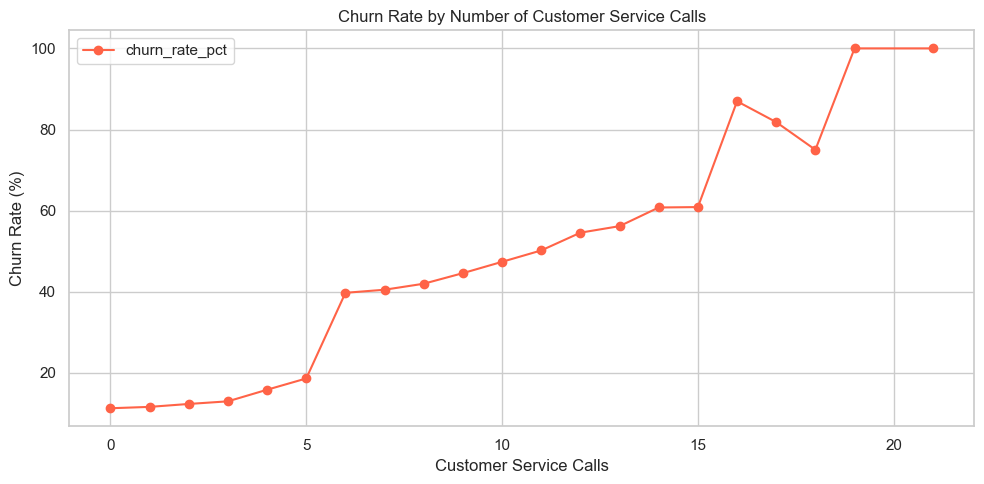

In [17]:
query = """
SELECT 
    CAST(Customer_Service_Calls AS INT) AS calls,
    COUNT(*) AS total_customers,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY calls
ORDER BY calls
"""
result = pd.read_sql(query, conn)
print(result.to_string(index=False))

result.plot(kind='line', x='calls', y='churn_rate_pct', marker='o', color='tomato')
plt.title('Churn Rate by Number of Customer Service Calls')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Service Calls')
plt.tight_layout()
plt.savefig('data/churn_by_service_calls.png', dpi=120)
plt.show()

### Q7: Do high-discount users churn more?

In [18]:
query = """
SELECT 
    CASE 
        WHEN Discount_Usage_Rate < 25 THEN 'Low (<25%)'
        WHEN Discount_Usage_Rate BETWEEN 25 AND 50 THEN 'Medium (25-50%)'
        WHEN Discount_Usage_Rate BETWEEN 50 AND 75 THEN 'High (50-75%)'
        ELSE 'Very High (>75%)'
    END AS discount_group,
    COUNT(*) AS total_customers,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(Average_Order_Value), 2) AS avg_order_value
FROM customers
GROUP BY discount_group
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,discount_group,total_customers,churn_rate_pct,avg_order_value
0,Low (<25%),11345,35.50,123.74
1,Medium (25-50%),22555,27.83,122.80
2,Very High (>75%),3457,26.03,123.07
3,High (50-75%),12643,25.67,123.14


### Q8: How does login frequency impact churn?

In [19]:
query = """
SELECT 
    CASE 
        WHEN Login_Frequency < 5 THEN 'Low (<5)'
        WHEN Login_Frequency BETWEEN 5 AND 15 THEN 'Medium (5-15)'
        WHEN Login_Frequency BETWEEN 15 AND 25 THEN 'High (15-25)'
        ELSE 'Very High (>25)'
    END AS login_group,
    COUNT(*) AS total_customers,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY login_group
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,login_group,total_customers,churn_rate_pct
0,Low (<5),10156,47.35
1,Medium (5-15),25030,26.75
2,High (15-25),12262,20.60
3,Very High (>25),2552,16.46


### Q9: Which signup quarter has the highest long-term churn?

In [20]:
query = """
SELECT 
    Signup_Quarter,
    COUNT(*) AS total_customers,
    SUM(Churned) AS churned,
    ROUND(SUM(Churned) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY Signup_Quarter
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,Signup_Quarter,total_customers,churned,churn_rate_pct
0,Q2,12521,3715,29.67
1,Q1,12453,3651,29.32
2,Q3,12558,3570,28.43
3,Q4,12468,3514,28.18


### Q10: Who are the top 10 highest-value customers at risk of churning?

In [21]:
query = """
SELECT 
    customer_id,
    Country,
    Age,
    Lifetime_Value,
    Total_Purchases,
    Customer_Service_Calls,
    Cart_Abandonment_Rate,
    Days_Since_Last_Purchase
FROM customers
WHERE Churned = 0
    AND Days_Since_Last_Purchase > 60
    AND Customer_Service_Calls >= 5
    AND Cart_Abandonment_Rate > 60
ORDER BY Lifetime_Value DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,customer_id,Country,Age,Lifetime_Value,Total_Purchases,Customer_Service_Calls,Cart_Abandonment_Rate,Days_Since_Last_Purchase
0,18039,Germany,32.0,3356.60,14.0,5.0,61.5,61.0
1,14737,UK,28.0,3333.68,16.9,5.0,63.3,67.0
2,37974,UK,25.0,3191.04,19.0,5.0,64.2,85.0
3,13852,USA,55.0,3151.21,27.0,5.0,66.9,71.0
4,24770,Germany,52.0,3061.65,15.0,5.0,65.9,66.0
5,7321,USA,36.0,2915.59,10.0,5.0,60.2,67.0
6,36106,Australia,35.0,2893.33,18.2,5.0,62.3,64.0
7,32461,Canada,43.0,2854.67,16.0,5.0,62.1,113.0
8,18946,USA,29.0,2690.50,13.0,5.0,62.9,143.0
9,41030,UK,19.0,2586.37,15.0,5.0,68.0,79.0


## 7. Key Findings Summary

In [22]:
# Summary statistics by churn status
summary = df.groupby('Churned')[[
    'Age', 'Login_Frequency', 'Cart_Abandonment_Rate',
    'Customer_Service_Calls', 'Lifetime_Value', 'Days_Since_Last_Purchase'
]].mean().round(2)
summary.index = ['Active', 'Churned']
print('Mean values — Active vs. Churned:')
summary

Mean values — Active vs. Churned:


,Age,Login_Frequency,Cart_Abandonment_Rate,Customer_Service_Calls,Lifetime_Value,Days_Since_Last_Purchase
Active,38.55,12.64,54.19,5.18,1446.81,26.54
Churned,35.99,9.12,64.18,6.90,1425.42,35.97


In [23]:
conn.close()
print('Analysis complete. Database connection closed.')

Analysis complete. Database connection closed.
